In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style='whitegrid')

In [3]:
data=pd.read_csv("amazon.csv")
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [9]:
print(data.shape)

(1465, 16)


In [11]:
print(data.columns)

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [17]:
data.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [21]:
# check null values
print(data.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [25]:
# drop missing values
data.dropna(inplace=True)

In [29]:
# remove duplicates
data.drop_duplicates(inplace=True)

In [31]:
# check null values
print(data.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [37]:
# Convert price columns (remove ₹ and commas)
data['discounted_price'] = pd.to_numeric(
    data['discounted_price'].replace('[₹,]', '', regex=True),
    errors='coerce'
)

data['actual_price'] = pd.to_numeric(
    data['actual_price'].replace('[₹,]', '', regex=True),
    errors='coerce'
)

# Convert rating safely
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')

# Convert rating count safely
data['rating_count'] = pd.to_numeric(
    data['rating_count'].replace(',', '', regex=True),
    errors='coerce'
)

In [39]:
# Fill missing values
data['discounted_price'].fillna(data['discounted_price'].mean(), inplace=True)
data['actual_price'].fillna(data['actual_price'].mean(), inplace=True)
data['rating'].fillna(data['rating'].mean(), inplace=True)
data['rating_count'].fillna(0, inplace=True)

In [43]:
#feature engineering
# Create discount percentage
data['discount_percent'] = ((data['actual_price'] - data['discounted_price']) / data['actual_price']) * 100

# Create target column (classification)
data['High_Rating'] = data['rating'].apply(lambda x: 1 if x >= 4 else 0)

In [45]:
# EDA 

In [61]:
#Top Categories


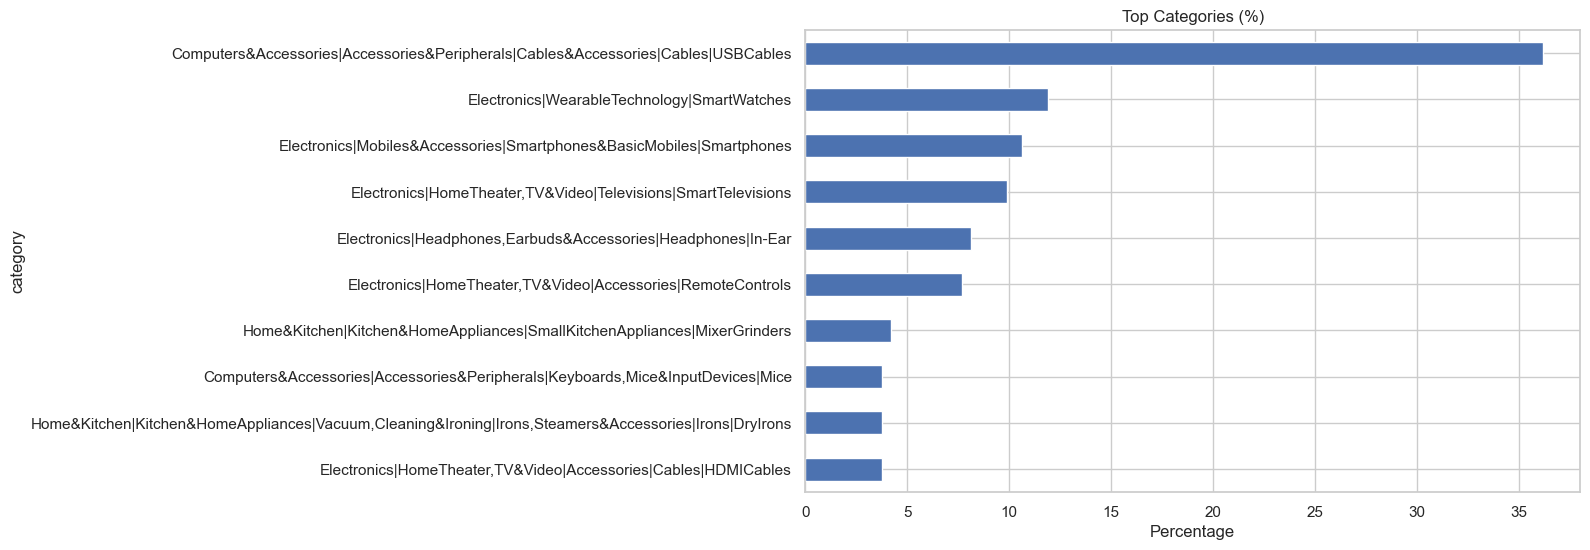

In [67]:
top_cat = data['category'].value_counts().head(10)
percent = (top_cat / top_cat.sum()) * 100

plt.figure(figsize=(10,6))
percent.sort_values().plot(kind='barh')

plt.title("Top Categories (%)")
plt.xlabel("Percentage")

plt.show()

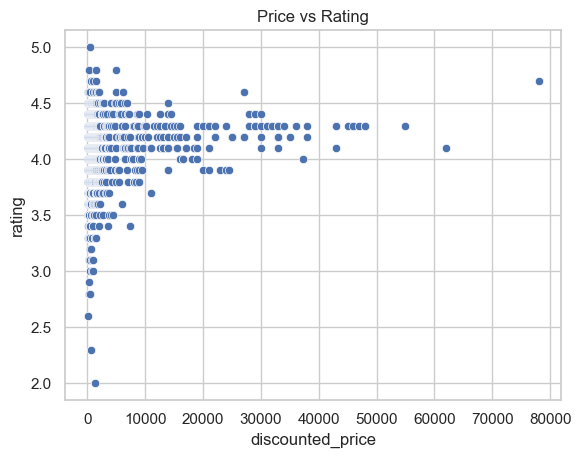

In [85]:
#Price vs Rating
plt.figure()
sns.scatterplot(x='discounted_price', y='rating', data=data_sorted)
plt.title("Price vs Rating")
plt.show()

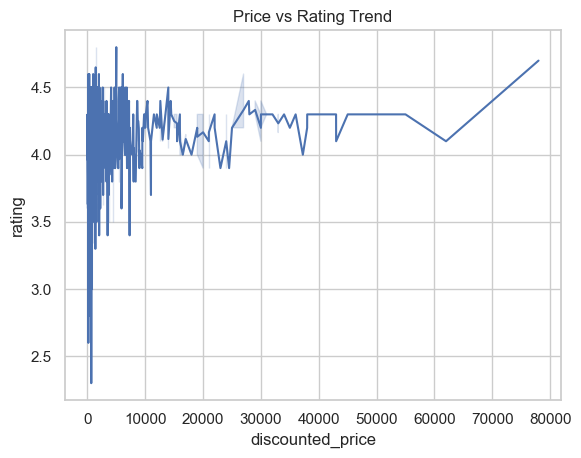

In [79]:
data_sorted = data.sort_values(by='discounted_price')

plt.figure()
sns.lineplot(x='discounted_price', y='rating', data=data_sorted)
plt.title("Price vs Rating Trend")
plt.show()

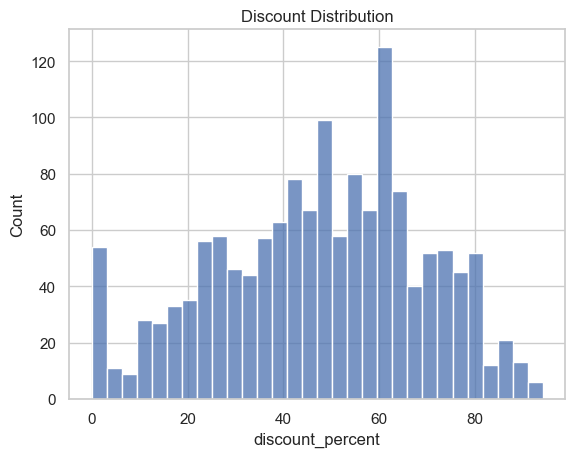

In [89]:
# Discout Distribution
plt.figure()
sns.histplot(data['discount_percent'], bins=30)
plt.title("Discount Distribution")
plt.show()

In [95]:
# data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode category
le = LabelEncoder()
data['category'] = le.fit_transform(data['category'])

# Features
X = data[['discounted_price', 'actual_price', 'rating_count', 'discount_percent', 'category']]
y = data['High_Rating']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [97]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

results = {}
predictions = {}

In [109]:
#linear kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

results['SVM Linear'] = accuracy_score(y_test, y_pred_linear)
predictions['SVM Linear'] = y_pred_linear


In [103]:
#rbf kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

results['SVM RBF'] = accuracy_score(y_test, y_pred_rbf)
predictions['SVM RBF'] = y_pred_rbf

In [105]:
#Polynomial Kernel
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

results['SVM Poly'] = accuracy_score(y_test, y_pred_poly)
predictions['SVM Poly'] = y_pred_poly

In [111]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

results['Random Forest'] = accuracy_score(y_test, y_pred_rf)
predictions['Random Forest'] = y_pred_rf

In [113]:
print(results)

{'SVM Linear': 0.78839590443686, 'SVM RBF': 0.78839590443686, 'SVM Poly': 0.78839590443686, 'Random Forest': 0.8088737201365188}


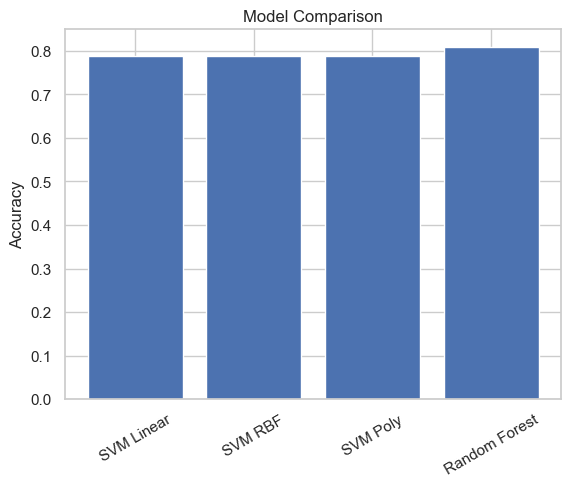

In [115]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.show()

In [117]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Random Forest


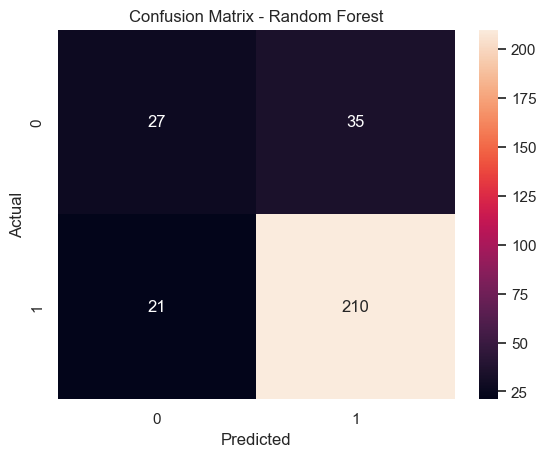

In [119]:
import seaborn as sns

best_pred = predictions[best_model]

cm = confusion_matrix(y_test, best_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()